<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Sinema_predict19attemptpROMPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Установка необходимых библиотек
!pip install pandas openpyxl transformers torch scikit-learn matplotlib seaborn imbalanced-learn peft datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)
from sklearn.metrics import auc
import os
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
# Определение устройства (GPU или CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# Загрузка файла в Google Colab
uploaded = files.upload()  # Загружаем файл sinema5.xlsx

# Чтение данных из Excel файла
df = pd.read_excel('sinema5.xlsx', sheet_name='Лист1')

Saving sinema5.xlsx to sinema5.xlsx


In [5]:
# Преобразование столбцов к соответствующим типам данных
df['name'] = df['name'].astype(str)
df['genre'] = df['genre'].astype(str)
df['tagline'] = df['tagline'].fillna('').astype(str)
df['logline'] = df['logline'].fillna('').astype(str)
df['annotation'] = df['annotation'].astype(str)
df['rezult2'] = df['rezult2'].astype(int)

# Заменим нулевые строки на пустые
df.replace('0', '', inplace=True)

In [6]:
# Создание промптов
def create_prompt(row, train_mode=True):
    prompt = f"""Оцени успешность фильма по данным:
Название: {row['name']}
Жанр: {row['genre']}
Слоган: {row['tagline']}
Логлайн: {row['logline']}
Описание: {row['annotation']}
Будет ли фильм успешным? (Да/Нет):"""

    if train_mode:
        prompt += f" {'Да' if row['rezult2'] == 1 else 'Нет'}"

    return prompt

In [7]:
# Класс датасета
class MovieDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = create_prompt(self.data.iloc[idx])
        label = self.data.iloc[idx]['rezult2']

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [8]:
# Модель с LoRA
def create_peft_model(model):
    peft_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        inference_mode=False,
        r=16,
        lora_alpha=32,
        lora_dropout=0.1,
        target_modules=["classifier.dense","classifier.out_proj"] #target_modules=["classifier"]  # Corrected target_modules
    )
    return get_peft_model(model, peft_config)

In [9]:
# Метрики
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted'),
        'roc_auc': roc_auc_score(labels, pred.predictions[:, 1])
    }

In [10]:
df

,ID_kinopoisk,genre,name,tagline,logline,annotation,rezult2
0,70952,драма триллер боевик,72 МЕТРА,,Моряки затонувшей подлодки пытаются спастись. ...,Капитан-лейтенанты Пётр Орлов и Иван Муравьёв ...,0
1,77396,фантастика комедия приключения криминал,ДАЖЕ НЕ ДУМАЙ 2,Нереальная молодежная комедия,,Приключения полюбившейся зрителям троицы герое...,0
2,79850,фантастика боевик фэнтези,НОЧНОЙ ДОЗОР,All That Stands Between Light And Darkness Is ...,"Маги и вампиры в современной Москве. Фильм, до...","Ночью можно столкнуться с темными магами, вамп...",1
3,253754,драма,ТЕМНАЯ НОЧЬ,,,Главный герой - семнадцатилетний Александр - и...,0
4,252013,анимация,ЩЕЛКУНЧИК И МЫШИНЫЙ КОРОЛЬ,"Тысяча препятствий ждет того, кто хочет стать ...",,История Принца-Щелкунчика и Маши – это история...,0
...,...,...,...,...,...,...,...
1678,5118213,приключения,Квест,Когда всё пошло не по плану,Подростки из летнего лагеря отправляются на по...,Отцы двух подростков из обеспеченных семей — н...,0
1679,5356063,анимация семейный,"Руслан и Людмила. Больше, чем сказка",,"Пока женихи ищут похищенную княжну, она готови...","Людмила — прекрасна и отважна, как подобает до...",0
1680,5003770,детектив приключения семейный,Чижик-Пыжик возвращается,,"Дети ищут украденную скульптуру чижика, чтобы ...","Приехав на экскурсию в Санкт-Петербург, однокл...",0
1681,4667350,семейный приключения фантастика,Девочка Нина и похитители пианино,Главное — верить в чудеса,,Восьмилетняя Нина — активная и эмоциональная д...,0


In [11]:

# Основная функция
def main():
    # Загрузка данных

    # Разделение данных
    train_df, test_df = train_test_split(
        df,
        test_size=0.3,
        stratify=df['rezult2'],
        random_state=42
    )

    # Инициализация токенизатора
    tokenizer = AutoTokenizer.from_pretrained("ai-forever/ru-en-RoSBERTa")
    tokenizer.pad_token = tokenizer.eos_token

    # Создание датасетов
    train_dataset = MovieDataset(train_df, tokenizer)
    test_dataset = MovieDataset(test_df, tokenizer)

    # Загрузка модели
    model = AutoModelForSequenceClassification.from_pretrained(
        "ai-forever/ru-en-RoSBERTa",
        num_labels=2
    ).to(device)

    # Добавление LoRA
    model = create_peft_model(model)
    model.print_trainable_parameters()

    # Параметры обучения
    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=12,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=500,
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=100,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss", # Изменено для предотвращения переобучения
        greater_is_better=False,
        report_to="none"
    )

    # Колбэк для ранней остановки
    early_stopping = EarlyStoppingCallback(
        early_stopping_patience=3,
        early_stopping_threshold=0.01
    )

    # Инициализация тренера
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        callbacks=[early_stopping]
    )

    # Обучение
    trainer.train()

    # Оценка
    results = trainer.evaluate(test_dataset)
    print("\nFinal Evaluation Results:")
    print(pd.DataFrame([results]))

    # Предсказание на тестовых данных
    test_preds = trainer.predict(test_dataset)
    y_true = test_dataset.data['rezult2']
    y_pred = np.argmax(test_preds.predictions, axis=-1)

    # Вывод отчета классификации
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Вывод матрицы ошибок
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    # ROC AUC Curve
    y_scores = test_preds.predictions[:, 1]  # Вероятности для класса 1
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    # Interactive prediction
    interactive_prediction(trainer.model, tokenizer)


In [12]:
# Интерактивное предсказание
def interactive_prediction(model, tokenizer):
    model.eval()  # Set the model to evaluation mode

    while True:
        try:
            name = input("Название фильма: ")
            genre = input("Жанр: ")
            tagline = input("Слоган: ")
            logline = input("Логлайн: ")
            annotation = input("Описание: ")
        except EOFError:
            print("\nExiting interactive prediction.")
            break

        # Create a DataFrame from the inputs
        input_data = pd.DataFrame([{
            'name': name,
            'genre': genre,
            'tagline': tagline,
            'logline': logline,
            'annotation': annotation,
            'rezult2': 0  # Dummy value
        }])

        # Generate prompt
        prompt_text = create_prompt(input_data.iloc[0], train_mode=False)

        # Tokenize the prompt
        inputs = tokenizer(
            prompt_text,
            return_tensors="pt",
            max_length=512,
            truncation=True,
            padding='max_length'
        ).to(device)

        # Make prediction
        with torch.no_grad():
            outputs = model(**inputs)
            probabilities = torch.softmax(outputs.logits, dim=1)
            prediction = torch.argmax(probabilities).item()

            # Extract probability
            predicted_probability = probabilities[0, prediction].item()

        # Output the result
        result = "Успешным" if prediction == 1 else "Неуспешным"
        print(f"Прогноз: Фильм будет {result} (Вероятность: {predicted_probability:.4f})\n")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.49M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.82M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/5.99M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.61G [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


trainable params: 1,100,834 || all params: 405,909,572 || trainable%: 0.2712


Epoch,Training Loss,Validation Loss,Accuracy,F1,Roc Auc
1,0.512800,0.337320,0.893069,0.842624,0.606348
2,0.346400,0.394285,0.893069,0.842624,0.727396
3,0.301400,0.307832,0.895050,0.886217,0.785661
4,0.302300,0.257114,0.908911,0.892860,0.821261
5,0.209500,0.248230,0.914851,0.900549,0.850168
6,0.237000,0.267596,0.908911,0.887887,0.855588
7,0.190300,0.260992,0.920792,0.904034,0.870617



Final Evaluation Results:
   eval_loss  eval_accuracy   eval_f1  eval_roc_auc  eval_runtime  \
0    0.24823       0.914851  0.900549      0.850168       44.9532   

   eval_samples_per_second  eval_steps_per_second  epoch  
0                   11.234                  1.424    7.0  

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       451
           1       0.72      0.33      0.46        54

    accuracy                           0.91       505
   macro avg       0.82      0.66      0.70       505
weighted avg       0.90      0.91      0.90       505


Confusion Matrix:
[[444   7]
 [ 36  18]]


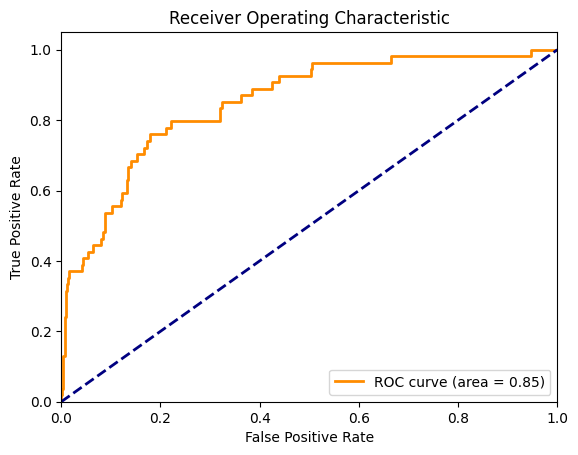

Название фильма: Холоп
Жанр: комедия мелодрама
Слоган: Из князи в грязи
Логлайн: Мажор просыпается в деревне XIX века. Комедия с Милошем Биковичем, которая стала рекордсменом проката
Описание: 27-летний московский мажор Григорий ошалел от безнаказанности. Богатый папа стабильно его отмазывает, да так, что уже обновил автопарк и оборудование отделению полиции, где служит начальником его друг. После очередной выходки терпение отца иссякает, и он обращается к психологу, практикующему шоковые методы воздействия на пациентов.  Вскоре сынуля попадает в аварию и приходит в себя на деревенской конюшне. На дворе — Россия 1860 года, а сам он — бесправный конюх Гришка, которому за любую провинность и ослушание всегда готовы всыпать плетей, а то и вздёрнуть на глазах у всего честного народа.
Прогноз: Фильм будет Неуспешным (Вероятность: 0.8257)

Название фильма: Пальма 2
Жанр:  драмасемейный
Слоган: 
Логлайн: 
Описание: Оставив большую авиацию, летчик Вячеслав Лазарев с семьей перебирается в глуби

In [ ]:
if __name__ == "__main__":
    main()